# Women's E-Commerce Clothing Reviews
https://www.kaggle.com/datasets/nicapotato/womens-ecommerce-clothing-reviews

In [2]:
import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download("nicapotato/womens-ecommerce-clothing-reviews")


files = os.listdir(path)
print("다운로드된 파일 목록:", files)

csv_file = [f for f in files if f.endswith('.csv')][0] # 첫 번째 CSV 파일을 자동으로 선택
full_path = os.path.join(path, csv_file)


df = pd.read_csv(full_path, index_col=0)

print("\n데이터 로드 완료.")
print(df.head())

100%|██████████| 2.79M/2.79M [00:00<00:00, 108MB/s]

Extracting files...


다운로드된 파일 목록: ['Womens Clothing E-Commerce Reviews.csv']

데이터 로드 완료.
   Clothing ID  Age                    Title  \
0          767   33                      NaN   
1         1080   34                      NaN   
2         1077   60  Some major design flaws   
3         1049   50         My favorite buy!   
4          847   47         Flattering shirt   

                                         Review Text  Rating  Recommended IND  \
0  Absolutely wonderful - silky and sexy and comf...       4                1   
1  Love this dress!  it's sooo pretty.  i happene...       5                1   
2  I had such high hopes for this dress and reall...       3                0   
3  I love, love, love this jumpsuit. it's fun, fl...       5                1   
4  This shirt is very flattering to all due to th...       5                1   

   Positive Feedback Count   Division Name Department Name Class Name  
0                        0       Initmates        Intimate  Intimates  
1           

In [3]:
# 결측치 확인
print(df.isnull().sum())

# 리뷰 텍스트가 없는 행은 분석에서 제외하기
df = df.dropna(subset=['Review Text'])
print(f"\n남은 리뷰 개수: {len(df)}개")

Clothing ID                   0
Age                           0
Title                      3810
Review Text                 845
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                14
Department Name              14
Class Name                   14
dtype: int64

남은 리뷰 개수: 22641개


In [ ]:
df

,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses
...,...,...,...,...,...,...,...,...,...,...
23481,1104,34,Great dress for many occasions,I was very happy to snag this dress at such a ...,5,1,0,General Petite,Dresses,Dresses
23482,862,48,Wish it was made of cotton,"It reminds me of maternity clothes. soft, stre...",3,1,0,General Petite,Tops,Knits
23483,1104,31,"Cute, but see through","This fit well, but the top was very see throug...",3,0,1,General Petite,Dresses,Dresses
23484,1084,28,"Very cute dress, perfect for summer parties an...",I bought this dress for a wedding i have this ...,3,1,2,General,Dresses,Dresses


### 평점 분포 시각화

/tmp/ipykernel_16571/3977329205.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Rating', data=df, palette='viridis')


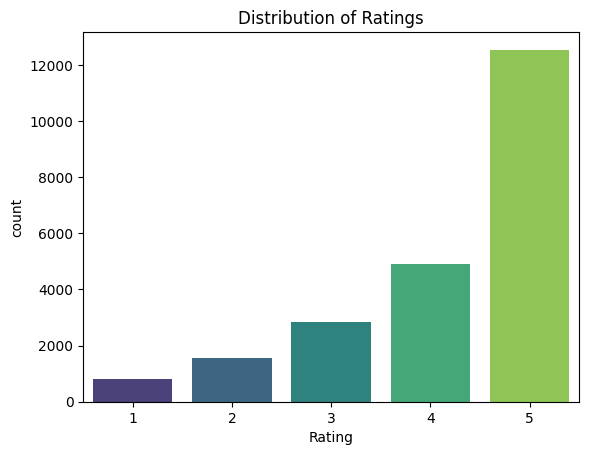

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Rating', data=df, palette='viridis')
plt.title('Distribution of Ratings')
plt.show()

In [ ]:
# 별점이 1점인 리뷰 5개만 출력
low_rating_reviews = df[df['Rating'] == 1]['Review Text']
print("별점 1점 리뷰 샘플:")
low_rating_reviews.head(5)

별점 1점 리뷰 샘플:


,Review Text
61,"3 tags sewn in, 2 small (about 1'' long) and 1..."
85,"I was really hoping to like this, but it did n..."
96,I usually wear a medium and bought a small. it...
97,I was very excited to order this top in red xs...
110,This is so thin and poor quality. especially f...


### 평점 별 Recommended IND 시각화

/tmp/ipykernel_1739/4228204833.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Recommended IND', data=df, palette='magma')


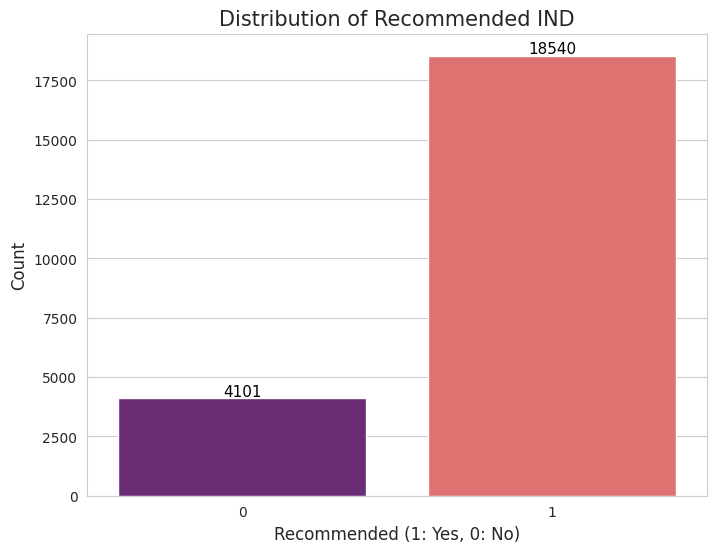

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(8, 6))

# 추천 여부 분포 시각화
ax = sns.countplot(x='Recommended IND', data=df, palette='magma')

plt.title('Distribution of Recommended IND', fontsize=15)
plt.xlabel('Recommended (1: Yes, 0: No)', fontsize=12)
plt.ylabel('Count', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

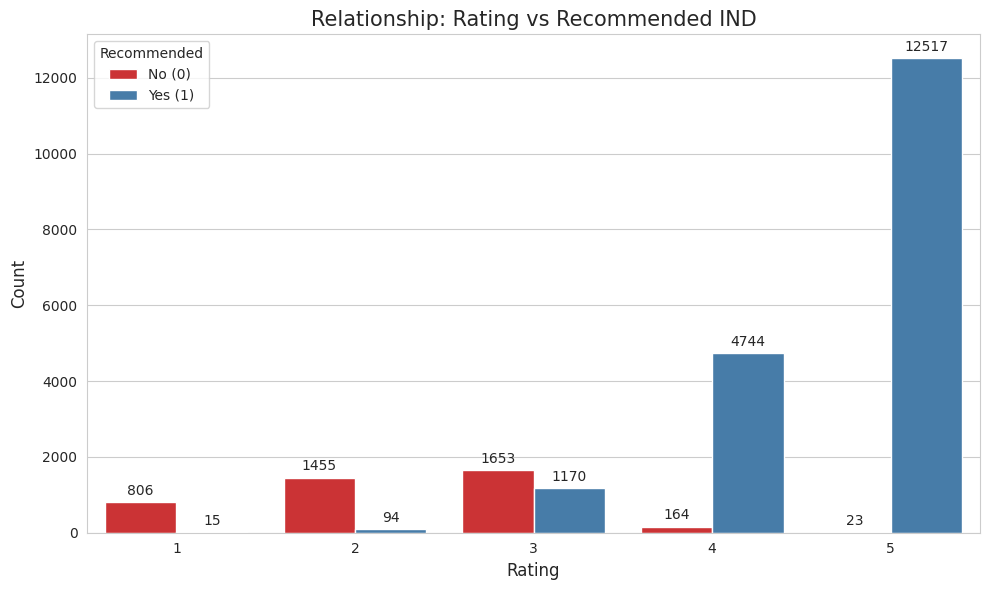

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

ax = sns.countplot(x='Rating', hue='Recommended IND', data=df, palette='Set1')

plt.title('Relationship: Rating vs Recommended IND', fontsize=15)
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Recommended', labels=['No (0)', 'Yes (1)'])

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3, fontsize=10)

plt.tight_layout()
plt.show()